<a href="https://colab.research.google.com/github/gayatrichopade11/DeepThought-Assignment-Gayatri/blob/main/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index.csv
Saving historical_data.csv to historical_data.csv


In [ ]:
trader = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

print("Trader Dataset")
display(trader.head())

print("Fear & Greed Dataset")
display(sentiment.head())

Trader Dataset


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


Fear & Greed Dataset


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
print(trader.info())

print(sentiment.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [ ]:
print("Trader Shape :",trader.shape)

print("Sentiment Shape :",sentiment.shape)

Trader Shape : (211224, 16)
Sentiment Shape : (2644, 4)


In [ ]:
print(trader.isnull().sum())

print(sentiment.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [ ]:
print(trader.duplicated().sum())

print(sentiment.duplicated().sum())

0
0


In [ ]:
trader.drop_duplicates(inplace=True)

sentiment.drop_duplicates(inplace=True)

In [ ]:
trader['Timestamp IST'] = pd.to_datetime(trader['Timestamp IST'], format='%d-%m-%Y %H:%M')

trader['Date'] = trader['Timestamp IST'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date'], format='%Y-%m-%d')

sentiment['Date'] = sentiment['date'].dt.date

In [ ]:
merged=pd.merge(
    trader,
    sentiment[['Date','classification','value']],
    on='Date',
    how='left'
)

In [ ]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [ ]:
merged.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,value
count,211224.000000,2.112240e+05,2.112240e+05,211224,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05,211218.000000
mean,11414.723350,4.623365e+03,5.639451e+03,2025-01-31 12:04:22.915009792,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12,51.649656
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,10.000000
25%,4.854700,2.940000e+00,1.937900e+02,2024-12-31 21:00:45,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12,33.000000
50%,18.280000,3.200000e+01,5.970450e+02,2025-02-24 18:55:00,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12,49.000000
75%,101.580000,1.879025e+02,2.058960e+03,2025-04-02 18:22:00,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12,72.000000
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,94.000000
std,29447.654868,1.042729e+05,3.657514e+04,NaN,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09,21.012784


In [ ]:
merged.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'classification', 'value'],
      dtype='object')

In [ ]:
merged["Closed PnL"].sum()

np.float64(10296958.943436)

In [ ]:
merged["Closed PnL"].mean()

np.float64(48.74900079269401)

In [ ]:
merged["Closed PnL"].max()

135329.0901

In [ ]:
merged["Closed PnL"].min()

-117990.1041

In [ ]:
merged["Coin"].value_counts().head(10)

,count
Coin,
HYPE,68005
@107,29992
BTC,26064
ETH,11158
SOL,10691
FARTCOIN,4650
MELANIA,4428
PURR/USDC,2774
WLD,1983


In [ ]:
merged.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False).head(10)

,Closed PnL
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05


In [ ]:
merged.groupby("Account")["Closed PnL"].sum().sort_values().head(10)

,Closed PnL
Account,
0x8170715b3b381dffb7062c0298972d4727a0a63b,-167621.124781
0x271b280974205ca63b716753467d5a371de622ab,-70436.191318
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-31203.599986
0x39cef799f8b69da1995852eea189df24eb5cae3c,14456.919336
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f,14900.443047
0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb,21758.831753
0xb899e522b5715391ae1d4f137653e7906c5e2115,22488.500821
0x8477e447846c758f5a675856001ea72298fd9cb5,43917.008976
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,47885.320514


In [ ]:
merged["Side"].value_counts()

,count
Side,
SELL,108528
BUY,102696


In [ ]:
merged.groupby("Side")["Closed PnL"].mean()

,Closed PnL
Side,
BUY,36.104730
SELL,60.713803


In [ ]:
merged.groupby("classification")["Closed PnL"].mean()

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


In [ ]:
merged.groupby("classification")["Closed PnL"].sum()

,Closed PnL
classification,
Extreme Fear,7.391102e+05
Extreme Greed,2.715171e+06
Fear,3.357155e+06
Greed,2.150129e+06
Neutral,1.292921e+06


In [ ]:
merged.groupby("classification")["Size USD"].sum()

,Size USD
classification,
Extreme Fear,1.144843e+08
Extreme Greed,1.244652e+08
Fear,4.833248e+08
Greed,2.885825e+08
Neutral,1.802421e+08


In [ ]:
merged.groupby("classification")["Size USD"].mean()

,Size USD
classification,
Extreme Fear,5349.731843
Extreme Greed,3112.251565
Fear,7816.109931
Greed,5736.884375
Neutral,4782.732661


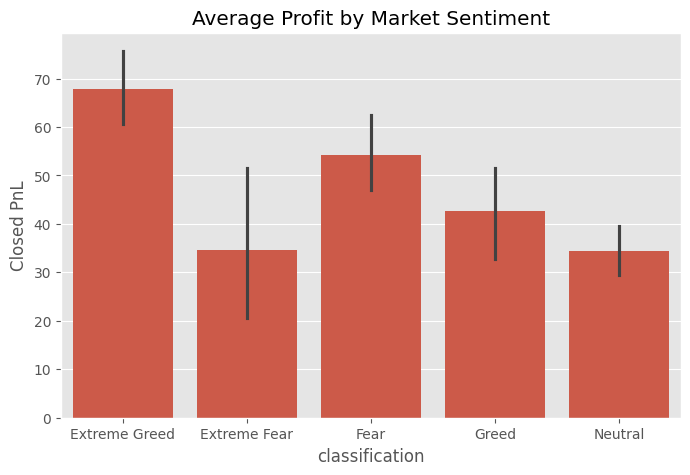

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=merged,
    x="classification",
    y="Closed PnL",
    estimator=np.mean
)

plt.title("Average Profit by Market Sentiment")
plt.show()

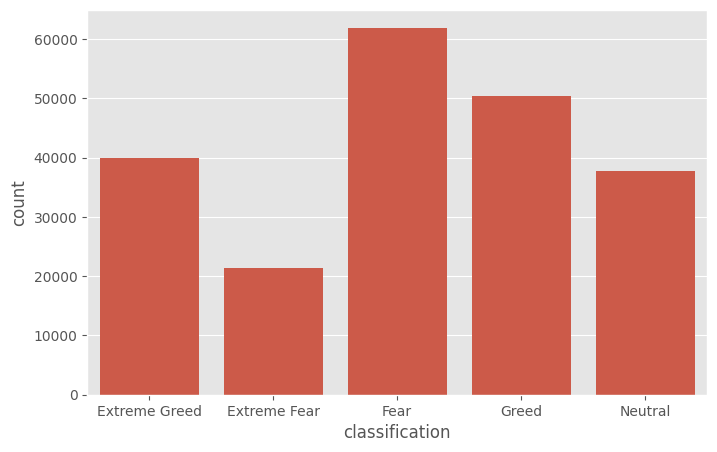

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged,
    x="classification"
)

plt.show()

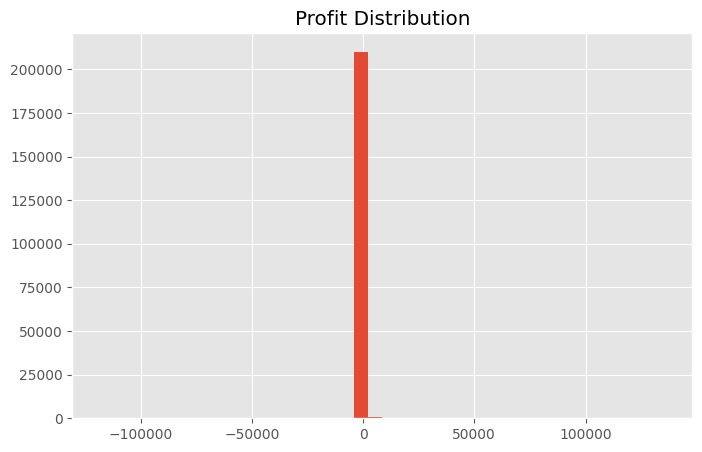

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(merged["Closed PnL"],bins=40)

plt.title("Profit Distribution")

plt.show()

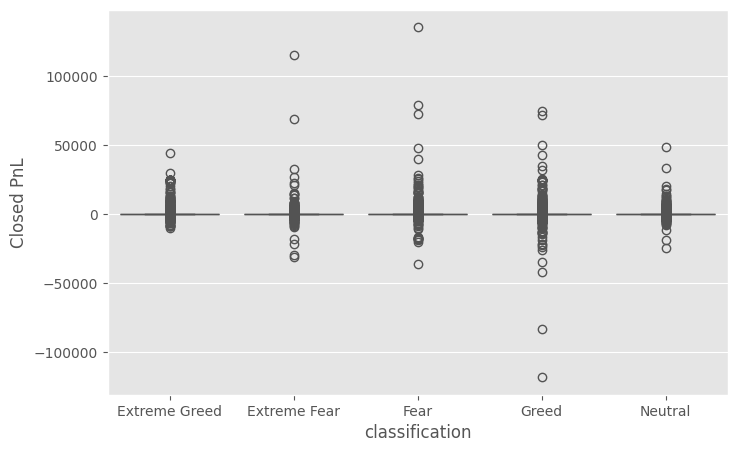

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged,
    x="classification",
    y="Closed PnL"
)

plt.show()

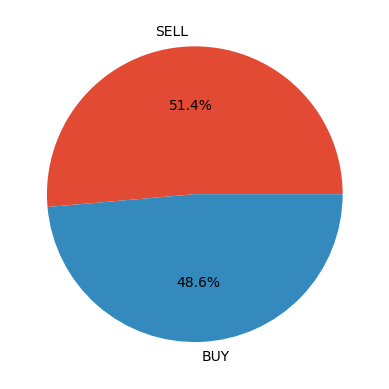

In [ ]:
merged["Side"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.show()

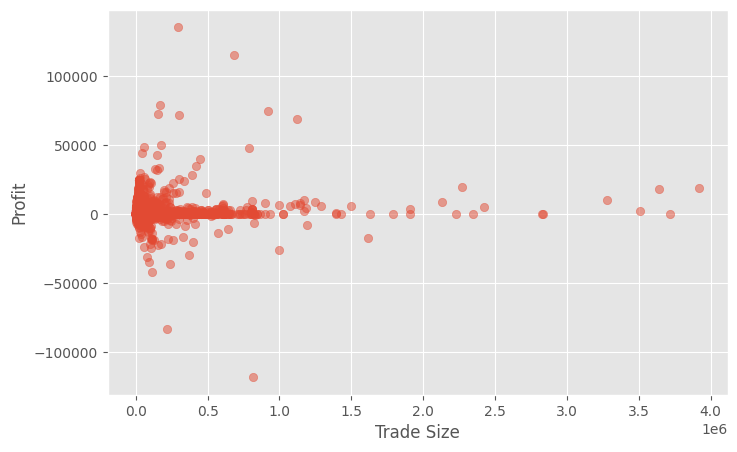

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    merged["Size USD"],
    merged["Closed PnL"],
    alpha=0.5
)

plt.xlabel("Trade Size")

plt.ylabel("Profit")

plt.show()

In [ ]:
corr=merged[["Execution Price","Size USD","Closed PnL","Fee","value"]].corr()

corr

,Execution Price,Size USD,Closed PnL,Fee,value
Execution Price,1.000000,0.189855,-0.006505,0.225265,-0.027558
Size USD,0.189855,1.000000,0.123589,0.745939,-0.029843
Closed PnL,-0.006505,0.123589,1.000000,0.084020,0.008121
Fee,0.225265,0.745939,0.084020,1.000000,-0.026877
value,-0.027558,-0.029843,0.008121,-0.026877,1.000000


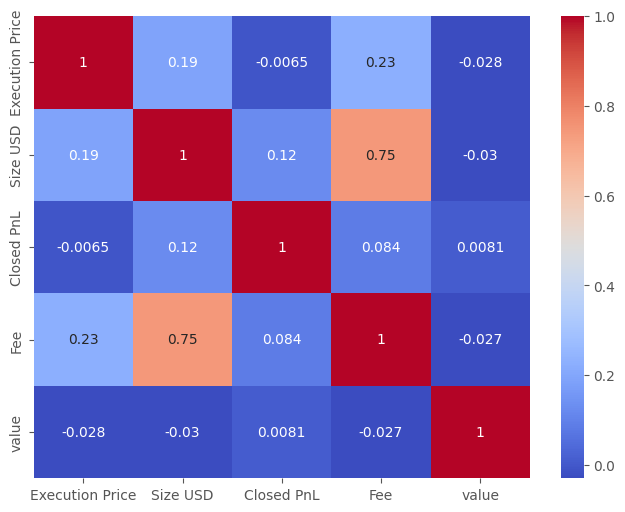

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

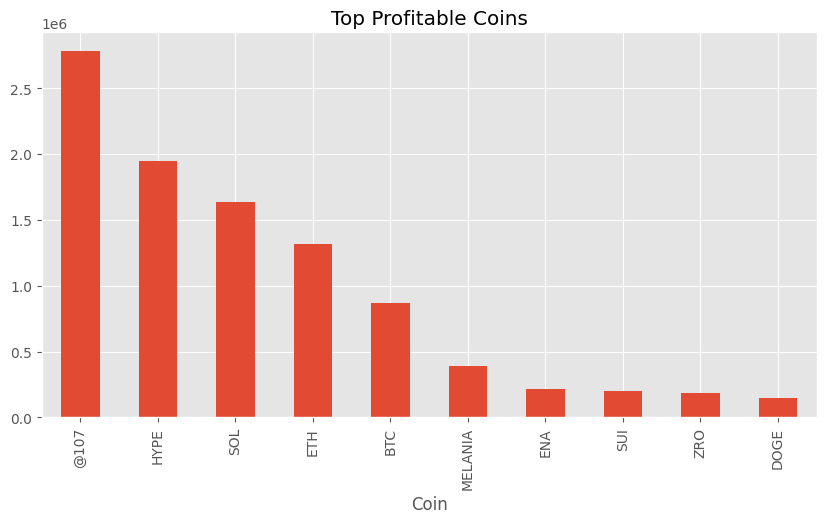

In [ ]:
coin_profit=merged.groupby("Coin")["Closed PnL"].sum().sort_values(ascending=False).head(10)

coin_profit.plot(kind="bar",figsize=(10,5))

plt.title("Top Profitable Coins")

plt.show()

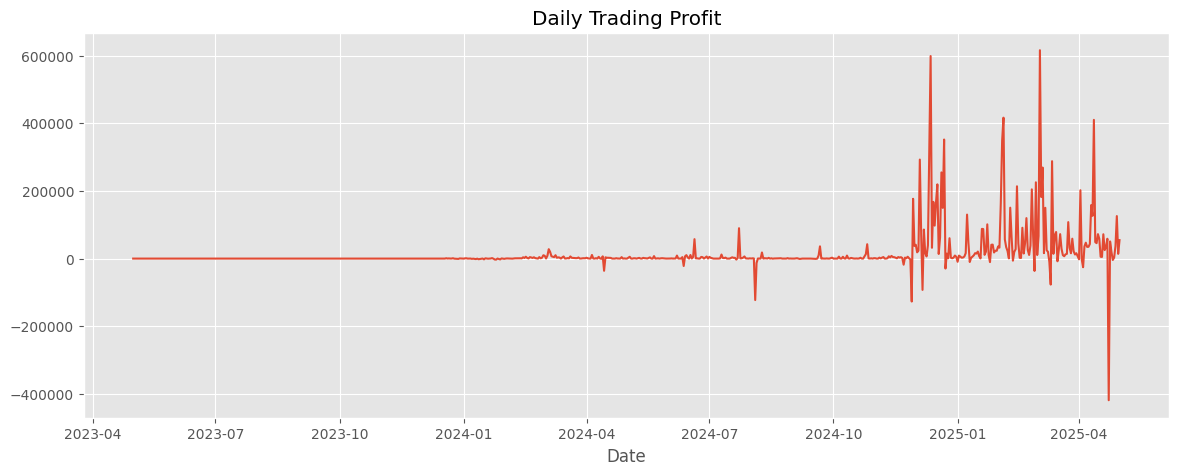

In [ ]:
daily=merged.groupby("Date")["Closed PnL"].sum()

daily.plot(figsize=(14,5))

plt.title("Daily Trading Profit")

plt.show()

In [ ]:
merged.to_csv("merged_dataset.csv",index=False)   8ik